In [113]:
# Task 1.
# Текстурные характеристики:
#  - Реализуйте подсчет гистограммы 
#  - Реализуйте рассчет текстурных характеристик Laws 
#  - Реализуйте расчет текстурных характеристик на основе матрицы взаимной встречаемости GLCM
# Для каждого случая: выполните тренировку классификатора (knn, svm, trees)
# Решите задачу сегментации данных на основе классификации изображений каждым методом.
# Выполните ручную разметку изображений на регионы.
# Сравните результат полученной классификации и размеченной.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, jaccard_score
from skimage.feature import graycomatrix, graycoprops
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from scipy.stats import entropy, skew, kurtosis
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.base import clone
import warnings

## Текстурные характеристики:

## - Реализуйте подсчет гистограммы 

In [114]:
def compute_histogram(image, bins):
    hist = cv2.calcHist([image], [0], None, [bins], [0, 256])
    hist = hist.flatten()
    bin_width = 256 / bins
    bin_centers = np.array([i * bin_width + bin_width / 2 for i in range(bins)])
    hist_normalized = hist / np.sum(hist)
    
    weighted_data = np.repeat(bin_centers, hist.astype(int))
    
    features = {
        'mean': np.average(bin_centers, weights=hist),
        'variance': np.var(weighted_data) if len(weighted_data) > 0 else 0,
        'std_dev': np.std(weighted_data) if len(weighted_data) > 0 else 0,
        'skewness': skew(weighted_data) if len(weighted_data) > 0 else 0,
        'kurtosis': kurtosis(weighted_data) if len(weighted_data) > 0 else 0,
        'energy': np.sum(hist_normalized**2),
        'entropy': entropy(hist_normalized),
        'median': np.median(image),
        'percentile_25': np.percentile(image, 25),
        'percentile_75': np.percentile(image, 75),
        'min': np.min(image),
        'max': np.max(image),
        'contrast': np.max(image) - np.min(image)
    }
    
    return features, hist_normalized

In [115]:
def select_an_image(i:int, j:int):
    image_folder = "./KTH_TIPS"
    texture_name = os.listdir(image_folder)[i]
    texture_path = os.path.join(image_folder, texture_name)
    image_files = [f for f in os.listdir(texture_path)]
    image_path = os.path.join(texture_path, image_files[j])
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    return image, texture_name

In [116]:
def show_image_hist(image, texture_name):
    bins_count = 256
    features, hist = compute_histogram(image, bins=bins_count)

    fig, (ax_img, ax_hist, ax_stats) = plt.subplots(1, 3, figsize=(15, 4))

    ax_img.imshow(image, cmap='gray')
    ax_img.set_title(texture_name)
    ax_img.axis('off')

    ax_hist.bar(range(bins_count), hist, alpha=0.7)
    ax_hist.set_title('Гистограмма')
    ax_hist.set_xlabel('Яркость')
    ax_hist.set_ylabel('Вероятность')

    stats_text = '\n'.join([f'{k}: {v:.2f}' for k, v in features.items()])
    ax_stats.text(0.05, 0.95, stats_text, transform=ax_stats.transAxes, verticalalignment='top')
    ax_stats.set_title('Характеристики')
    ax_stats.axis('off')

    plt.tight_layout()
    plt.show()

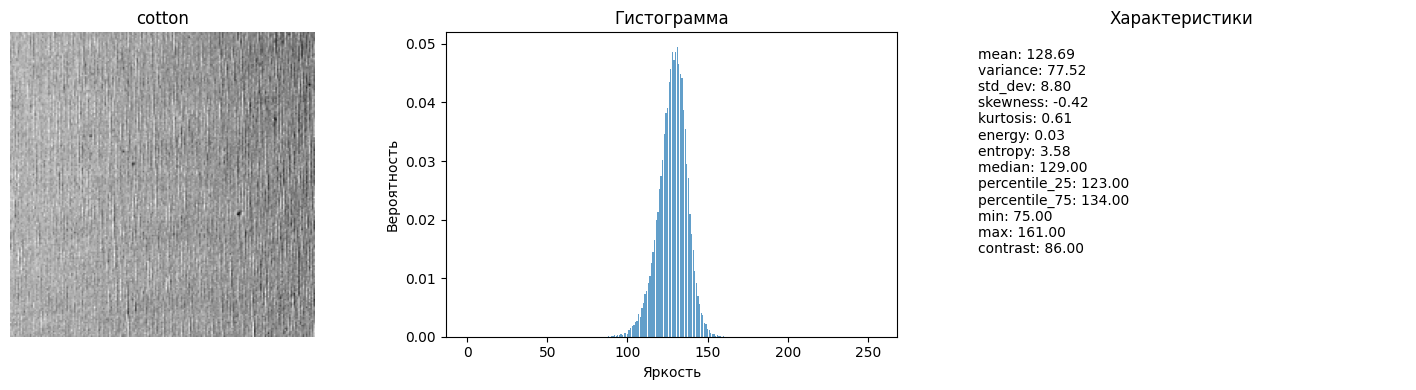

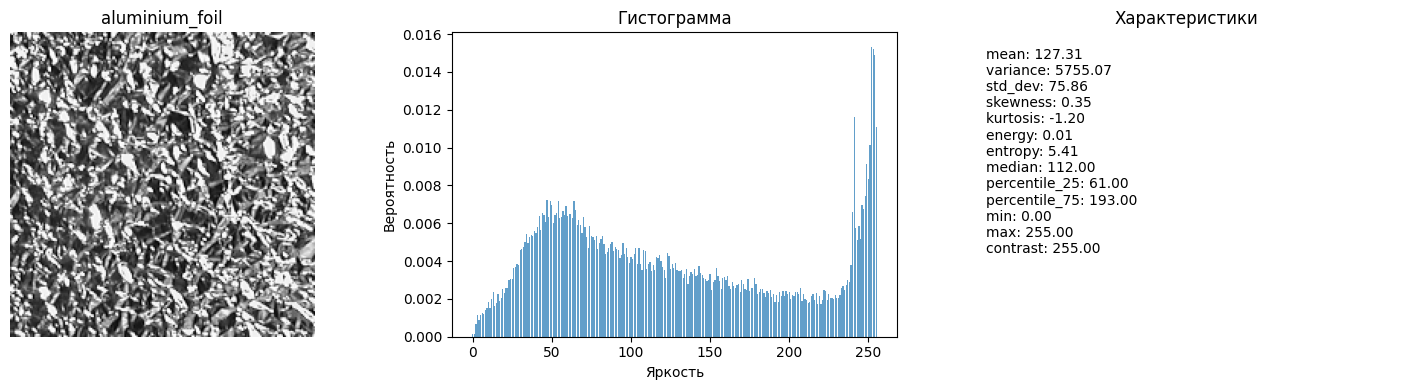

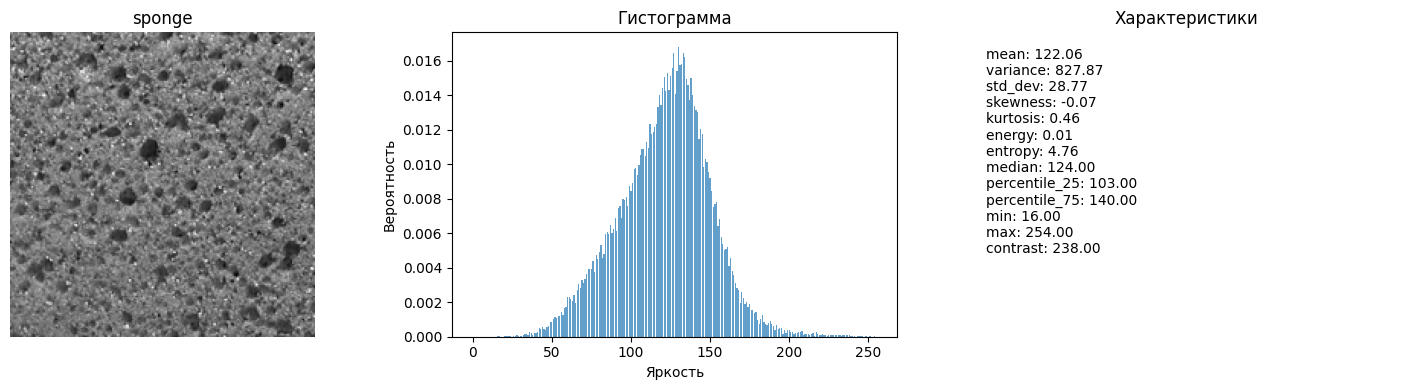

In [117]:
image1, texture_name1 = select_an_image(2, 9)
image2, texture_name2 = select_an_image(5, 10)
image3, texture_name3 = select_an_image(0, 7)

show_image_hist(image1, texture_name1)
show_image_hist(image2, texture_name2)
show_image_hist(image3, texture_name3)

## - Реализуйте рассчет текстурных характеристик Laws

In [118]:
def laws_texture(image):
    kernels = [
        ([1,4,6,4,1], 'L5'),
        ([-1,-2,0,2,1], 'E5'),
        ([-1,0,2,0,-1], 'S5'),
        ([-1,2,0,-2,1], 'W5'),
        ([1,-4,6,-4,1], 'R5')
    ]
    
    features_dict = {}
    
    for k1, name1 in kernels:
        for k2, name2 in kernels:
            kernel = np.outer(k1, k2)
            filtered = cv2.filter2D(image.astype(np.float32), -1, kernel)
            features_dict[f"{name1}{name2}"] = np.mean(filtered ** 2)
    
    total = sum(features_dict.values())
    if total > 0:
        for key in features_dict:
            features_dict[key] /= total
    
    return features_dict

In [119]:
def show_laws_for_image(image, texture_name, features_dict):
    fig, (ax_img, ax_stats) = plt.subplots(1, 2, figsize=(12, 4))

    ax_img.imshow(image, cmap='gray')
    ax_img.set_title(texture_name)
    ax_img.axis('off')

    top = sorted(features_dict.items(), key=lambda x: x[1], reverse=True)[:5]
    stats_text = '\n'.join([f'{k}: {v:.4f}' for k, v in top])

    ax_stats.text(0.1, 0.9, stats_text, transform=ax_stats.transAxes, verticalalignment='top')
    ax_stats.set_title('Топ 5 Характеристик Laws')
    ax_stats.axis('off')

    plt.tight_layout()
    plt.show()

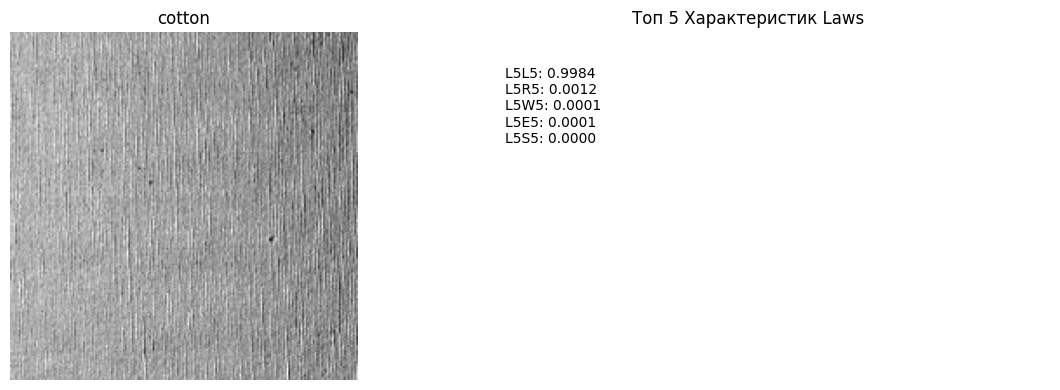

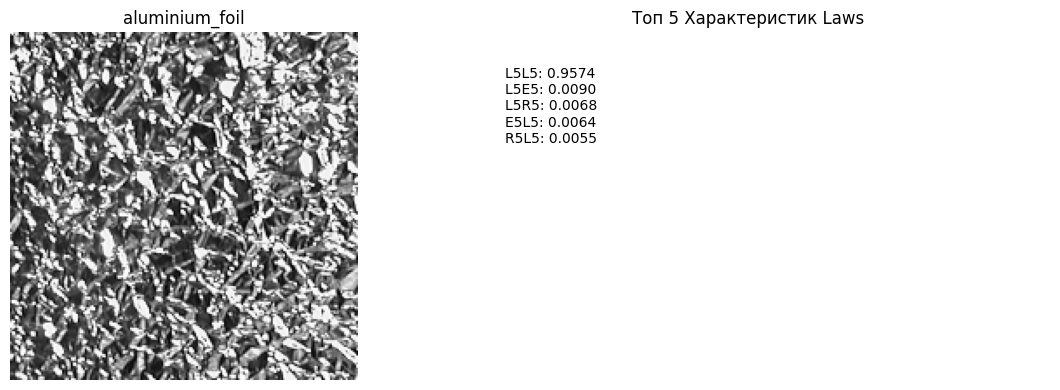

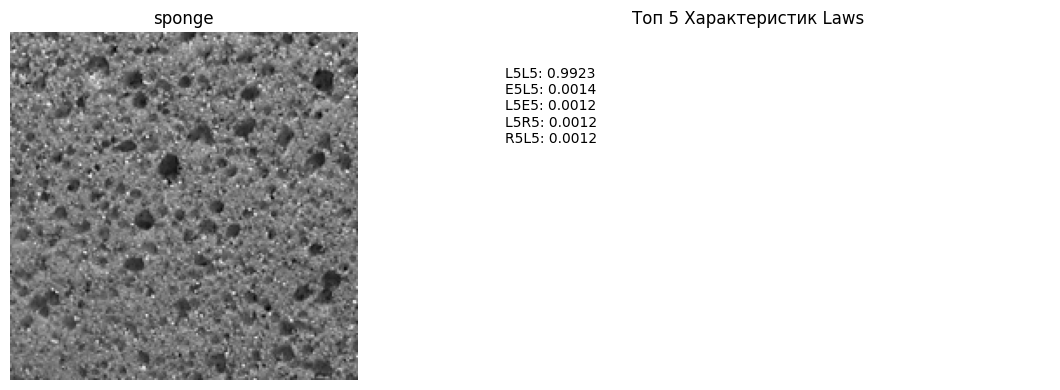

In [120]:
features_dict1 = laws_texture(image1)
features_dict2 = laws_texture(image2)
features_dict3 = laws_texture(image3)

show_laws_for_image(image1, texture_name1, features_dict1)
show_laws_for_image(image2, texture_name2, features_dict2)
show_laws_for_image(image3, texture_name3, features_dict3)

## - Реализуйте расчет текстурных характеристик на основе матрицы взаимной встречаемости GLCM

In [121]:
def compute_glcm_features(image):
    distances = [1]
    angles = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
    image_quantized = (image // 8).astype(np.uint8)
    glcm = graycomatrix(
        image_quantized, 
        distances=distances, 
        angles=angles, 
        levels=32, 
        symmetric=True, 
        normed=True
    )
    
    properties = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
    features = {}
    
    for prop in properties:
        feature_val = np.mean(graycoprops(glcm, prop))
        features[prop] = feature_val
    
    return features

In [122]:
def show_glcm_for_image(image, texture_name, features):
    fig, (ax_img, ax_stats) = plt.subplots(1, 2, figsize=(12, 4))

    ax_img.imshow(image, cmap='gray')
    ax_img.set_title(texture_name)
    ax_img.axis('off')

    stats_text = '\n'.join([f'{k}: {v:.2f}' for k, v in features.items()])

    ax_stats.text(0.1, 0.9, stats_text, transform=ax_stats.transAxes, verticalalignment='top')
    ax_stats.set_title('GLCM Характеристики')
    ax_stats.axis('off')

    plt.tight_layout()
    plt.show()

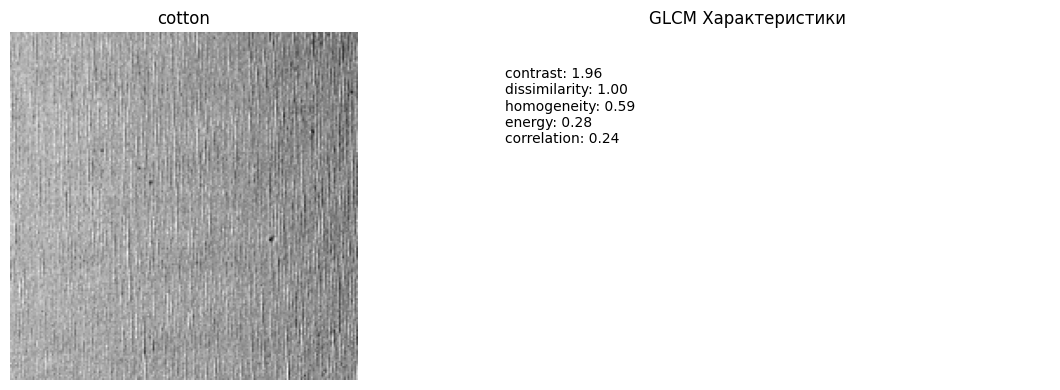

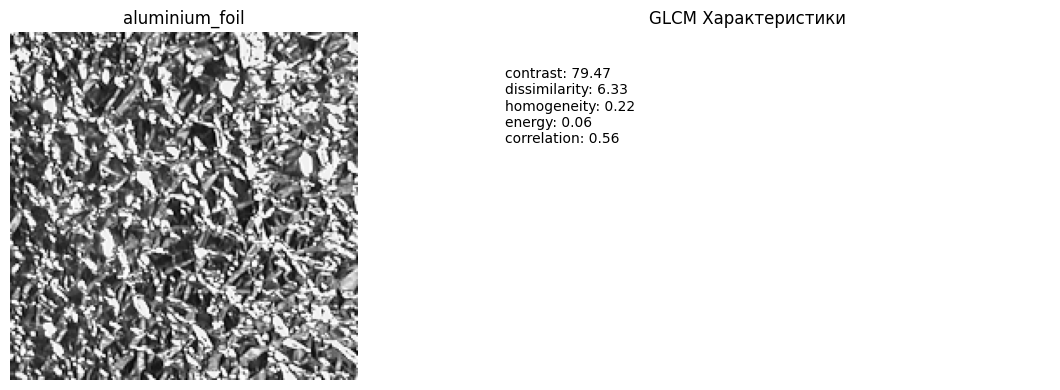

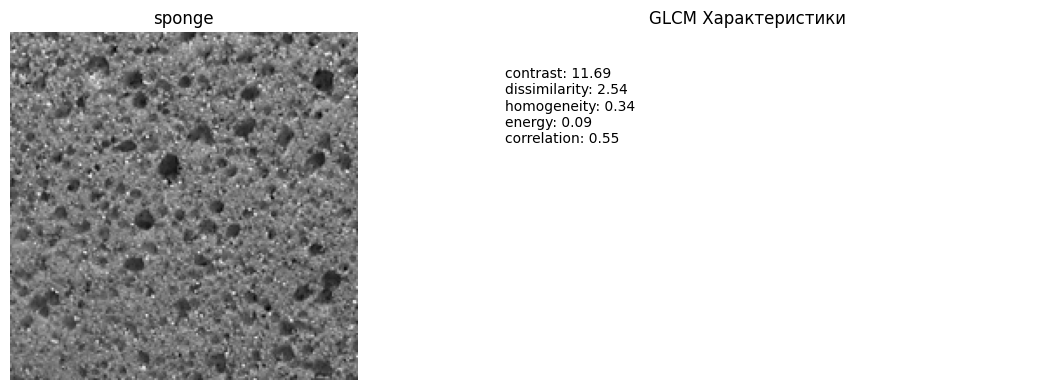

In [123]:
features1 = compute_glcm_features(image1)
features2 = compute_glcm_features(image2)
features3 = compute_glcm_features(image3)

show_glcm_for_image(image1, texture_name1, features1)
show_glcm_for_image(image2, texture_name2, features2)
show_glcm_for_image(image3, texture_name3, features3)

## Для каждого случая: выполните тренировку классификатора (knn, svm, trees)

In [124]:
def load_dataset(image_folder, feature_type):
    features, labels, texture_labels = [], [], []
    
    for texture_name in os.listdir(image_folder):
        texture_path = os.path.join(image_folder, texture_name)
        if not os.path.isdir(texture_path):
            continue
        texture_labels.append(texture_name)
        
        for image_file in os.listdir(texture_path):
            if image_file == '.DS_Store':
                continue
            image_path = os.path.join(texture_path, image_file)
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            
            if image is not None:
                image = cv2.resize(image, (128, 128))
                
                if feature_type == 'Histogram':
                    features_dict, _ = compute_histogram(image, 256)
                elif feature_type == 'Laws':
                    features_dict = laws_texture(image)
                else:
                    features_dict = compute_glcm_features(image)
                
                features.append(list(features_dict.values()))
                labels.append(texture_name)
    
    return np.array(features), labels, texture_labels

In [125]:
def train_models(X, y):
    y_encoded = LabelEncoder().fit_transform(y)
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    classifiers = {
        'KNN': KNeighborsClassifier(n_neighbors=3, n_jobs=-1),
        'SVM': SVC(kernel='rbf', random_state=42),
        'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=10)
    }
    
    models = {name: clf.fit(X_train_scaled, y_train) for name, clf in classifiers.items()}

    return models, X_test_scaled, y_test, scaler

In [126]:
trained_models_dict = {}

feature_types = ['Histogram', 'Laws', 'GLCM']
for feature_type in feature_types:
    print(f"Тренировка модели {feature_type}")
    
    X, labels, texture_labels = load_dataset("./KTH_TIPS", feature_type)
    models, X_test, y_test, scaler = train_models(X, labels)
    
    trained_models_dict[feature_type] = {
        'models': models, 'scaler': scaler
    }
    
    print(f"  Кол-во: {X.shape}")
    for name, model in models.items():
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
            f1 = report['macro avg']['f1-score']
        print(f"  {name}: Точность={accuracy:.3f}, F1={f1:.3f}")
        print(classification_report(y_test, y_pred, target_names=texture_labels))
        
    print()

Тренировка модели Histogram
  Кол-во: (810, 13)
  KNN: Точность=0.872, F1=0.874
                precision    recall  f1-score   support

        sponge       1.00      1.00      1.00        20
        cotton       1.00      0.90      0.95        20
   orange_peel       0.66      0.95      0.78        20
      corduroy       0.74      0.81      0.77        21
aluminium_foil       0.90      0.86      0.88        21
       cracker       0.94      0.80      0.86        20
     styrofoam       1.00      0.90      0.95        21
   brown_bread       0.76      0.65      0.70        20
     sandpaper       0.94      0.85      0.89        20
         linen       0.91      1.00      0.95        20

      accuracy                           0.87       203
     macro avg       0.89      0.87      0.87       203
  weighted avg       0.89      0.87      0.87       203

  SVM: Точность=0.818, F1=0.817
                precision    recall  f1-score   support

        sponge       1.00      1.00      1.0

## Решите задачу сегментации данных на основе классификации изображений каждым методом.

In [127]:
def texture_segmentation(image, trained_models_dict, feature_type, model_name, window_size=32, step=None, n_classes=4):
    original_image = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
    
    if step is None:
        step = window_size
    
    models = trained_models_dict[feature_type]['models']
    scaler = trained_models_dict[feature_type]['scaler']
    model = models[model_name]
    
    h, w = original_image.shape
    temp_seg_map = np.zeros((h, w), dtype=np.uint8)
    all_predictions = []
    
    feature_extractors = {
        'Histogram': lambda img: list(compute_histogram(img, 32)[0].values()),
        'Laws': lambda img: list(laws_texture(img).values()),
        'GLCM': lambda img: list(compute_glcm_features(img).values())
    }
    
    for y in range(0, h - window_size + 1, step):
        for x in range(0, w - window_size + 1, step):
            window = original_image[y:y+window_size, x:x+window_size]
            
            features = feature_extractors[feature_type](window)
            features_scaled = scaler.transform([features])
            prediction = model.predict(features_scaled)[0]
            
            temp_seg_map[y:y+window_size, x:x+window_size] = prediction
            all_predictions.append(prediction)
    
    unique, counts = np.unique(all_predictions, return_counts=True)
    top_classes = unique[np.argsort(counts)[-n_classes:]]
    
    segmentation_map = np.zeros_like(temp_seg_map)
    
    for new_class, old_class in enumerate(top_classes):
        segmentation_map[temp_seg_map == old_class] = new_class
    
    mask_not_top = ~np.isin(temp_seg_map, top_classes)
    if np.any(mask_not_top):
        segmentation_map[mask_not_top] = 1
    
    return segmentation_map, original_image

In [128]:
def show_segment(image, trained_models_dict, **kwargs):
    seg_map, original = texture_segmentation(image, trained_models_dict, **kwargs)
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
    
    ax1.imshow(original, cmap='gray')
    ax1.set_title('Изображение')
    ax1.axis('off')
    
    ax2.imshow(seg_map, cmap='tab10')
    ax2.set_title('Сегментация')
    ax2.axis('off')
    
    ax3.imshow(seg_map, cmap='tab10', alpha=0.8)
    ax3.imshow(original, cmap='gray', alpha=0.3)
    ax3.set_title('Покрытие')
    ax3.axis('off')
    
    plt.tight_layout()
    plt.show()

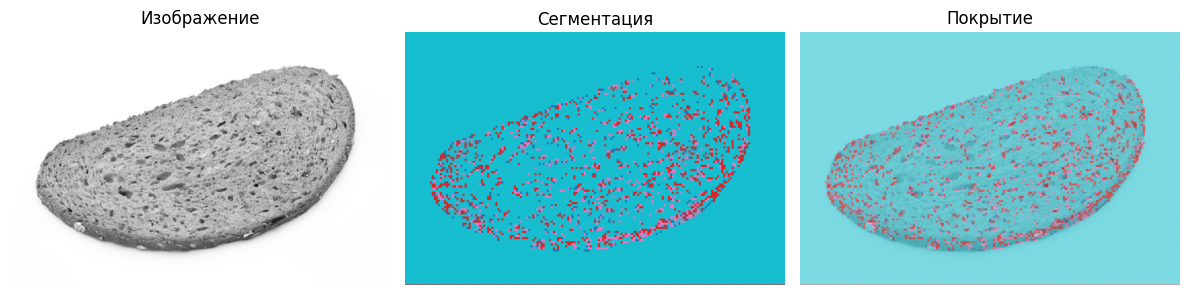

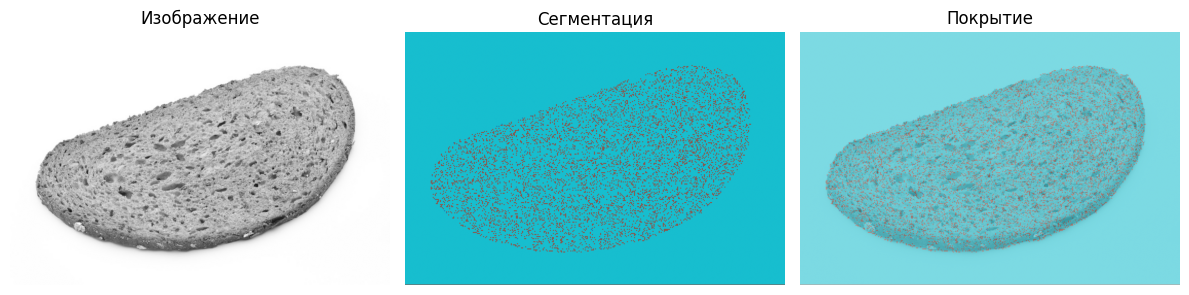

In [129]:
show_segment("./bread1.jpg", trained_models_dict, window_size=4, feature_type='Laws', model_name='SVM')
show_segment("./bread1.jpg", trained_models_dict, window_size=2, feature_type='GLCM', model_name='DecisionTree')

## Выполните ручную разметку изображений на регионы.

In [130]:
def manual_segment(image):
    image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    final_mask = np.zeros_like(mask)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(final_mask, [largest_contour], 0, 1, -1)
    
    return final_mask

In [131]:
def remap_classes(mask, n_classes):
    unique, counts = np.unique(mask, return_counts=True)
    top_classes = unique[np.argsort(-counts)[:n_classes]]

    result = np.zeros_like(mask)
    for new_id, old_id in enumerate(top_classes):
        result[mask == old_id] = new_id

    return result

In [132]:
image_path = "./bread1.jpg"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

manual_mask = manual_segment(image_rgb)
manual_mask = remap_classes(manual_mask, 4)

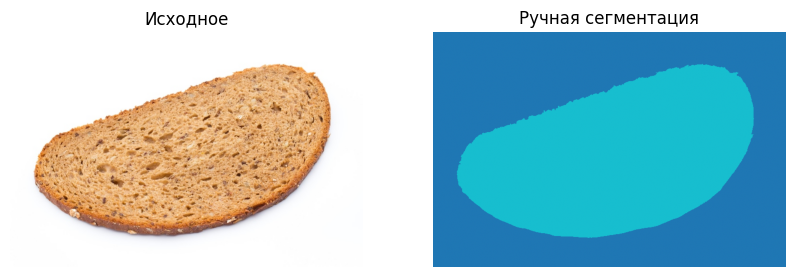

In [133]:
fig, (ax_orig, ax_segment) = plt.subplots(1, 2, figsize=(10, 5))

ax_orig.imshow(image_rgb)
ax_orig.set_title('Исходное')
ax_orig.axis('off')

ax_segment.imshow(manual_mask, cmap='tab10')
ax_segment.set_title('Ручная сегментация')
ax_segment.axis('off')

plt.show()

## Сравните результат полученной классификации и размеченной.

In [134]:
def find_best_mapping(true_mask, pred_mask):
    true_flat = true_mask.flatten()
    pred_flat = pred_mask.flatten()
    
    true_classes = np.unique(true_flat)
    pred_classes = np.unique(pred_flat)
    
    mapping = {}
    for pred_class in pred_classes:
        best_true_class = None
        best_overlap = -1
        
        for true_class in true_classes:
            overlap = np.sum((true_flat == true_class) & (pred_flat == pred_class))
            if overlap > best_overlap:
                best_overlap = overlap
                best_true_class = true_class
        
        mapping[pred_class] = best_true_class
    
    return mapping


def compare_segmentation(manual_mask, predicted_mask, original_img):
    if manual_mask.shape != predicted_mask.shape:
        predicted_mask = cv2.resize(predicted_mask, (manual_mask.shape[1], manual_mask.shape[0]))
    
    mapping = find_best_mapping(manual_mask, predicted_mask)
    pred_mapped = np.zeros_like(predicted_mask)
    
    for pred_class, true_class in mapping.items():
        pred_mapped[predicted_mask == pred_class] = true_class
    
    accuracy = accuracy_score(manual_mask.flatten(), pred_mapped.flatten())
    iou_scores = jaccard_score(manual_mask.flatten(), pred_mapped.flatten(), 
                              average=None, labels=np.unique(manual_mask))
    
    print(f"Точность: {accuracy:.1%}")
    
    print("IoU за класс:")
    for i, class_id in enumerate(np.unique(manual_mask)):
        print(f"  Класс {class_id}: {iou_scores[i]:.3f}")
    
    fig, (ax_orig, ax_manual, ax_pred) = plt.subplots(1, 3, figsize=(15, 5))
    
    ax_orig.imshow(original_img, cmap='gray')
    ax_orig.set_title('Исходное')
    ax_orig.axis('off')
    
    ax_manual.imshow(manual_mask, cmap='tab10')
    ax_manual.set_title('Ручная маска')
    ax_manual.axis('off')
    
    ax_pred.imshow(pred_mapped, cmap='tab10')
    ax_pred.set_title('Предсказанная маска')
    ax_pred.axis('off')
    
    plt.tight_layout()
    plt.show()

GLCM - DecisionTree

Точность: 64.6%
IoU за класс:
  Класс 0: 0.616
  Класс 1: 0.179


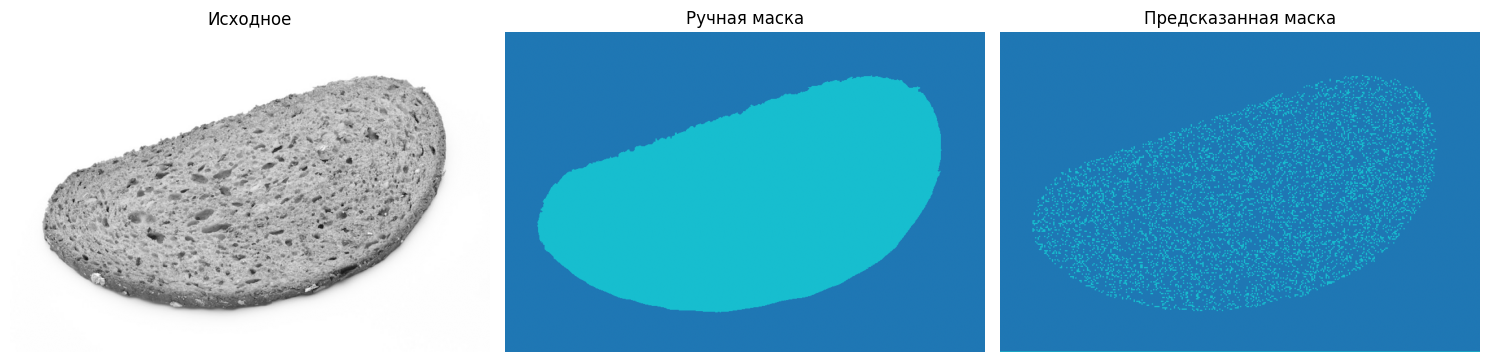

In [135]:
feature_type = 'GLCM'
model_name = 'DecisionTree'
print(f"{feature_type} - {model_name}\n")

predicted_mask, _ = texture_segmentation(
    image_path, 
    trained_models_dict,
     window_size=2, 
     feature_type=feature_type, 
     model_name=model_name
)

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
compare_segmentation(manual_mask, predicted_mask, image)